# Learning Neural Operators: An Example of DeepONet

Unlike classical numerical solvers that recompute a PDE solution for each new parameter setting, Scientific Machine Learning (SciML) uses **Neural Operators** to learn a reusable mapping from input functions (such as source terms) to solution functions.

## 1. Problem Setup: Steady-State Heat Equation

In this notebook, we approximate the solution of the Steady-State Heat Equation on $\Omega = [0,1]^2$:

  $$\kappa \nabla^2 u(x, y) + u_0(x, y) = 0, \quad u|_{\partial \Omega} = 0$$

- **Input ($u_0$):** source term (sampled as a Gaussian Random Field)  
- **Output ($u$):** temperature field  
- **Parameter:** $\kappa = 0.01$

### Why Neural Operators?

- **Traditional solvers (FEM/FDM):** A new PDE solve is needed for every new source term $u_0(x,y)$, which can be expensive.
- **Neural operators:** Learn a surrogate operator $G: u_0 \mapsto u$. After training, inference for unseen source terms is extremely fast, enabling near real-time prediction for design and optimization workflows.

## Trainee Implementation Tasks

Several parts of this notebook are intentionally incomplete and marked with `TODO`.  
Complete **TODO Steps 1–5**:

1. **TODO Step 1:** Implement the **Branch Network** in `DeepONet`.
2. **TODO Step 2:** Implement the **Trunk Network** in `DeepONet`.
3. **TODO Step 3:** Implement the **forward dot-product output** (e.g., via `torch.einsum`).
4. **TODO Step 4:** Complete the **training loop** (forward pass, loss, backward pass, optimizer step).
5. **TODO Step 5:** Complete the **evaluation loop** for test loss.

> **Goal:** Build a complete DeepONet pipeline, from architecture definition through training and performance evaluation.

If you need implementation hints, ask for guidance or compare with `./solutions/heat_eq_mlp_solution.ipynb`.

 ## 2. Environment Setup and Data Loading



 We mount Google Drive to access the dataset and set the working directory to the webinar folder.

In [1]:

from torch.utils.data import DataLoader, TensorDataset
import time
import torch.optim as optim
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
import numpy as np

import os
import sys
import gdown
# 1. Download data from Google Drive ONLY if it doesn't exist
url = "https://drive.google.com/drive/folders/1y36MEDzh0Hw1BONitlbxkDnkhDoe3KeY"
if not os.path.exists('./data/data_u0_train_ht.npy'):
    print("Downloading data from Google Drive...")
    gdown.download_folder(url)
# 2. Verify data is visible
!ls ./data/


README.md	       data_s_train_ht.npy     data_u0_train_ht.npy
data_s_testing_ht.npy  data_u0_testing_ht.npy  xy_train_test_ht.npy


 We load the training and testing datasets, which consist of source terms ($u_0$), temperature fields ($s$), and the spatial grid coordinates ($xy$).

In [2]:
# Load the datasets
num_samples = 1000  #TODO: you can use sub-dateset (e.g.1000) faster training in this demo, max=5000
# load the source term u0, which has shape (num_samples, num_grid_points) where num_grid_points=16384 for a 128x128 grid
u0_train = np.load(
    './data/data_u0_train_ht.npy').astype(np.float32)[:num_samples]
u0_testing = np.load('./data/data_u0_testing_ht.npy').astype(np.float32)
#load the solution s, which has the same shape as u0
s_train = np.load(
    './data/data_s_train_ht.npy').astype(np.float32)[:num_samples]
s_testing = np.load('./data/data_s_testing_ht.npy').astype(np.float32)
# load the grid coordinates (x, y), which has shape (num_grid_points, 2) where num_grid_points=16384 for a 128x128 grid
xy_coords = np.load('./data/xy_train_test_ht.npy').astype(np.float32)

print(f"Input (u0) Shape: {u0_train.shape}")   # (num_samples, num_grid_points)
print(f"Output (s) Shape: {s_train.shape}")    # (num_samples, num_grid_points)
print(f"Coordinate Shape: {xy_coords.shape}")  # (num_grid_points, 2)


Input (u0) Shape: (1000, 16384)
Output (s) Shape: (1000, 16384)
Coordinate Shape: (16384, 2)


 Visualization of a sample source term and its corresponding solution from the training set:

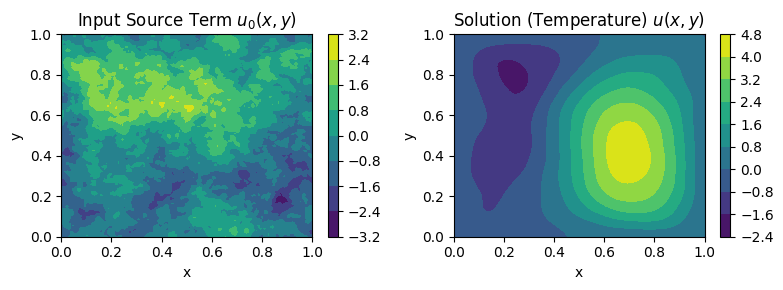

In [3]:
# Visualize one example from the training data
sample_idx = 0

# Reshape the data to 2D grid (128x128 based on 16384 points) for visualization
grid_size = int(np.sqrt(u0_train.shape[1]))
u0_sample = u0_train[sample_idx].reshape(grid_size, grid_size)
s_sample = s_train[sample_idx].reshape(grid_size, grid_size)
x_grid = xy_coords[:, 0].reshape(grid_size, grid_size)
y_grid = xy_coords[:, 1].reshape(grid_size, grid_size)


# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Plot input source term
im1 = axes[0].contourf(x_grid, y_grid, u0_sample,
                       cmap='viridis', origin='lower')
axes[0].set_title('Input Source Term $u_0(x, y)$')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
plt.colorbar(im1, ax=axes[0])

# Plot solution
im2 = axes[1].contourf(x_grid, y_grid, s_sample,
                       cmap='viridis', origin='lower')
axes[1].set_title('Solution (Temperature) $u(x, y)$')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()


 ## 3. DeepONet Architecture



 High-level structure:

 - **Branch Net (The "What")**: Encodes $u_0$ (evaluated at grid points) into a feature vector. It looks at the global input function (the source term $u_0$). It extracts "coefficients" or "features" that describe the specific scenario.

 - **Trunk Net (The "Where")**: Encodes coordinates $(x, y)$ into a feature vector. It looks at a specific coordinate $(x, y)$. It provides "basis functions" for the solution space.

 - **Output**: Dot product of branch and trunk features plus a bias: $G(u_0)(x, y) \approx \sum_{k=1}^{p} b_k(u_0) \cdot t_k(x, y) + b_0$. By multiplying the scenario-specific features (Branch) with the coordinate-specific basis (Trunk), we reconstruct the solution at any point in the domain.

**Note on Discretization:** Although training uses a \(128 \times 128\) grid, DeepONet is theoretically discretization-invariant. The Trunk network can evaluate the solution at any coordinate \((x, y)\), including points outside the original training grid.

 In this implementation, both sub-networks use fully connected layers (MLPs) with non-linear activations.


![DeepONet Architecture Diagram](./images/deeponet_architecture.png)


 ### Implementation Details

 The `DeepONet` class handles the dual network passes:

 1. **Branch**: Maps `branch_dim` (16384 grid points) to `latent_dim` (128) via multiple hidden layers (default: 5 layers of 100).

 2. **Trunk**: Maps `trunk_dim` (2D coordinates) to `latent_dim` (128) via similar MLP structure.

 3. **Forward**: Uses `torch.einsum` to compute the batch-wise inner product between branch and trunk signals.

In [4]:


class DeepONet(nn.Module):
    def __init__(self, branch_dim=16384, trunk_dim=2, latent_dim=128, br_hid_layers=[100]*5, tr_hid_layers=[100]*5):
        super(DeepONet, self).__init__()

        # Branch Network: Takes u0(x, y) values
        branch_layers = []
        # TODO Step1: Define the branch network architecture (self.branch) based on br_hid_layers
        # The input dimension for the branch network is branch_dim (16384 for 128x128 grid)
        # The output dimension of the branch network should be latent_dim
        # Hint: Use nn.Linear and activation layers (nn.ReLU, nn.Tanh, nn.SiLu...) to build the branch network
        # You can change the br_hid_layers list and latent_dim to experiment with different architectures
        input_dim = branch_dim
        for hidden_dim in br_hid_layers:
            branch_layers.append(nn.Linear(input_dim, hidden_dim))
            branch_layers.append(nn.ReLU())
            input_dim = hidden_dim
        branch_layers.append(nn.Linear(input_dim, latent_dim))
        self.branch = nn.Sequential(*branch_layers)

        # Trunk Network: Takes (x, y) coordinates
        trunk_layers = []
        # TODO Step2: Define the trunk network architecture (self.trunk) based on tr_hid_layers
        # The input dimension for the trunk network is trunk_dim (2 for (x, y) coordinates)
        # The output dimension of the trunk network should also be latent_dim
        # Hint: Use nn.Linear and activation layers (nn.ReLU, nn.Tanh, nn.SiLu...) to build the trunk network
        # You can change the tr_hid_layers list and latent_dim to experiment with different architectures
        input_dim = trunk_dim
        for hidden_dim in tr_hid_layers:
            trunk_layers.append(nn.Linear(input_dim, hidden_dim))
            trunk_layers.append(nn.ReLU())
            input_dim = hidden_dim
        trunk_layers.append(nn.Linear(input_dim, latent_dim))
        self.trunk = nn.Sequential(*trunk_layers)

        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, u0, xy):
        # u0: [batch, branch_dim]
        # xy: [N, 2] (coordinates)
        branch_out = self.branch(u0)  # [batch, latent_dim]
        trunk_out = self.trunk(xy)  # [N, latent_dim]

        # Dot product of the two outputs
        # TODO Step3: Compute the output of the DeepONet by taking the dot product of branch_out and trunk_out
        # The output should have shape [batch, N] where N is the number of coordinates (16384 for 128x128 grid)
        # Hint: Use torch.einsum to compute the dot product between branch_out and trunk_out
        res = torch.einsum('bi,ni->bn', branch_out, trunk_out) + self.bias
        return res

# Initialize the DeepONet model
don_model = DeepONet(branch_dim=16384, trunk_dim=2, latent_dim=128)


 ## 4. Data Preparation



 We normalize the source terms and solutions using training set statistics and create `DataLoader` instances with batch sizes 16 (train) and 128 (test).

In [5]:
u0_mean, u0_std = np.mean(u0_train), np.std(u0_train)
s_mean, s_std = np.mean(s_train), np.std(s_train)
u0_train_norm = (u0_train - u0_mean) / u0_std
s_train_norm = (s_train - s_mean) / s_std
u0_testing_norm = (u0_testing - u0_mean) / u0_std
s_testing_norm = (s_testing - s_mean) / s_std



In [6]:
# [num_samples, num_grid_points]
u0_train_norm = torch.from_numpy(u0_train_norm)
# [num_samples, num_grid_points]
s_train_norm = torch.from_numpy(s_train_norm)
xy_tensor = torch.from_numpy(xy_coords)  # [num_grid_points, 2]
# [num_samples, num_grid_points]
u0_testing_norm = torch.from_numpy(u0_testing_norm)
# [num_samples, num_grid_points]
s_testing_norm = torch.from_numpy(s_testing_norm)
xy_tensor = torch.from_numpy(xy_coords)  # [num_grid_points, 2]
train_dataset = TensorDataset(u0_train_norm, s_train_norm)
testing_dataset = TensorDataset(u0_testing_norm, s_testing_norm)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
testing_loader = DataLoader(testing_dataset, batch_size=128, shuffle=False)


 ## 5. Training Loop



 We optimize the model using the Adam optimizer ($lr=5 \times 10^{-4}$) and MSE loss. The training runs for 500 epochs, evaluating test loss at each step.

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Move model to the appropriate device (GPU if available, otherwise CPU)
don_model = don_model.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(don_model.parameters(), lr=5e-4)



In [8]:
# Move coordinates to the same device as the model
xy_tensor = xy_tensor.to(device)
epochs = 500
history = {"train_loss": [], "eval_loss": []}
for epoch in range(epochs):
    don_model.train()
    total_loss = 0
    s_timep = time.time()
    for u0_batch, s_batch in train_loader:
        # Move input and target batches to the same GPU as the model
        u0_batch = u0_batch.to(device)
        s_true_batch = s_batch.to(device)
        optimizer.zero_grad()
        # TODO Step4: Implement the training loop for one epoch
        # 1. Forward pass: Compute the model predictions for the entire grid using don_model(u0_batch, xy_tensor)
        # 2. Compute the loss using the criterion (MSELoss) against the true solution s_batch
        # 3. Backpropagation: Call loss.backward() and optimizer.step()
        s_pred_batch = don_model(u0_batch, xy_tensor)
        loss = criterion(s_pred_batch, s_true_batch)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    eval_loss = 0
    don_model.eval()
    for u0_batch, s_batch in testing_loader:
        u0_batch = u0_batch.to(device)
        s_true_batch = s_batch.to(device)
        with torch.no_grad():
            # TODO Step5: Implement the evaluation loop to compute evaluation loss
            # 1. Forward pass: Compute the model predictions for the entire grid using don_model(u0_batch, xy_tensor)
            # 2. Compute the loss using the criterion (MSELoss) against the true solution s_batch
            s_pred_batch = don_model(u0_batch, xy_tensor)
            batch_loss = criterion(s_pred_batch, s_true_batch)
            eval_loss += batch_loss.item()
    e_timep = time.time()
    history["train_loss"].append(total_loss/len(train_loader))
    history["eval_loss"].append(eval_loss/len(testing_loader))
    print(f"Epoch {epoch+1}/{epochs} took {e_timep - s_timep:.2f}s, Loss: {total_loss/len(train_loader):.4e}, Eval Loss: {eval_loss/len(testing_loader):.4e}")


Epoch 1/500 took 0.36s, Loss: 7.2282e-01, Eval Loss: 4.9121e-01
Epoch 2/500 took 0.20s, Loss: 4.7289e-01, Eval Loss: 2.6627e-01
Epoch 3/500 took 0.20s, Loss: 2.0634e-01, Eval Loss: 1.5742e-01
Epoch 4/500 took 0.21s, Loss: 1.4622e-01, Eval Loss: 1.3711e-01
Epoch 5/500 took 0.20s, Loss: 1.4009e-01, Eval Loss: 1.3763e-01
Epoch 6/500 took 0.20s, Loss: 1.3380e-01, Eval Loss: 1.3096e-01
Epoch 7/500 took 0.20s, Loss: 1.3398e-01, Eval Loss: 1.3498e-01
Epoch 8/500 took 0.20s, Loss: 1.3575e-01, Eval Loss: 1.4403e-01
Epoch 9/500 took 0.21s, Loss: 1.3492e-01, Eval Loss: 1.3084e-01
Epoch 10/500 took 0.20s, Loss: 1.2208e-01, Eval Loss: 1.1387e-01
Epoch 11/500 took 0.20s, Loss: 1.0161e-01, Eval Loss: 1.0848e-01
Epoch 12/500 took 0.21s, Loss: 1.0121e-01, Eval Loss: 1.0743e-01
Epoch 13/500 took 0.20s, Loss: 9.6466e-02, Eval Loss: 9.2379e-02
Epoch 14/500 took 0.21s, Loss: 8.6605e-02, Eval Loss: 8.2681e-02
Epoch 15/500 took 0.21s, Loss: 6.7371e-02, Eval Loss: 6.4398e-02
Epoch 16/500 took 0.20s, Loss: 5.8

 Visualizing the convergence of training and testing loss:

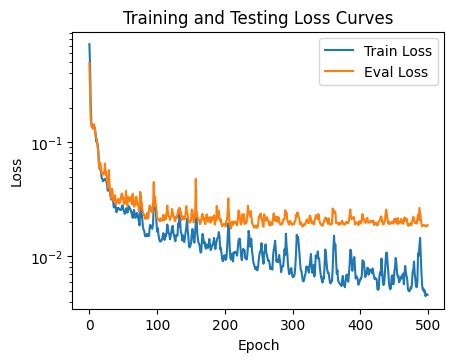

In [9]:
plt.figure(figsize=(4.8, 3.6))
plt.plot(history["train_loss"], label='Train Loss')
plt.plot(history["eval_loss"], label='Eval Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Training and Testing Loss Curves')
plt.legend()


 ## 6. Performance Evaluation



 After training, we evaluate accuracy using the L2 relative error on the test dataset. We then visualize predictions for the best, median, and worst-performing samples to check for physical consistency.

In [10]:
# We first compute the predictions of the DeepONet on the test set
don_model.eval()  # Set the model to evaluation mode
start_time = time.time()
pred_testing = don_model(u0_testing_norm.to(device), xy_tensor)
# We convert the normalized predictions back to the original scale
# We also move the prediction result to CPU for further analysis
pred_testing = pred_testing.cpu().detach().numpy() * s_std+s_mean
end_time = time.time()
print(f"Prediction took {end_time - start_time:.2f}s for {u0_testing_norm.shape[0]} samples")

Prediction took 0.01s for 100 samples


Mean L2 relative error of test dataset: 0.15879563987255096, std: 0.06439950317144394


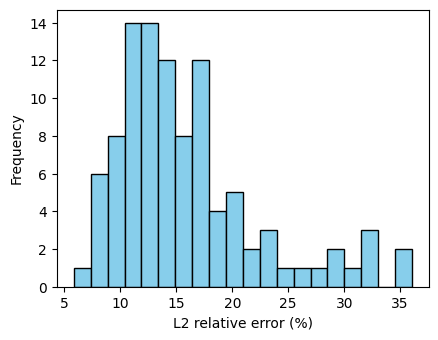

In [11]:
l2_error = np.linalg.norm(pred_testing - s_testing,
                          axis=1) / np.linalg.norm(s_testing, axis=1)
mean, std = np.mean(l2_error), np.std(l2_error)
print(f"Mean L2 relative error of test dataset: {mean}, std: {std}")
fig = plt.figure(figsize=(4.8, 3.6))
ax = plt.subplot(1, 1, 1)
_ = ax.hist(l2_error*100, bins=20,
            color="skyblue", edgecolor="black")
ax.set_xlabel("L2 relative error (%)")
ax.set_ylabel("Frequency")
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))


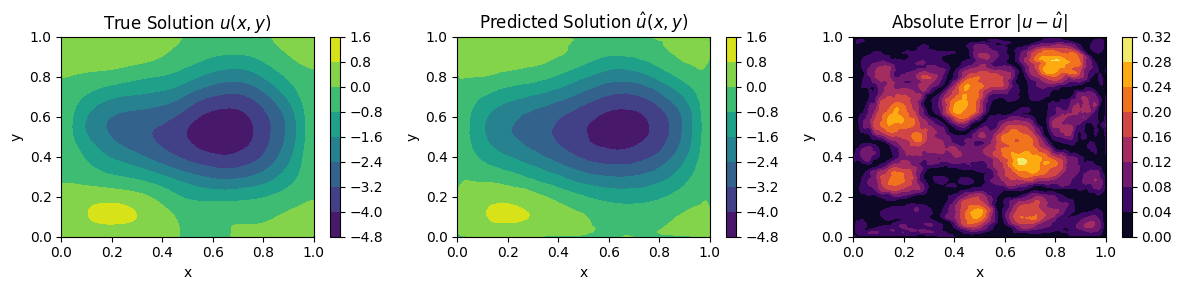

In [12]:
idx_sorted = np.argsort(l2_error)

visual_samples = {"Best": idx_sorted[0], "25%": idx_sorted[len(idx_sorted) // 4],
                  "Median": idx_sorted[len(idx_sorted) // 2], "75%": idx_sorted[3 * len(idx_sorted) // 4],
                  "Worst": idx_sorted[-1]}

visu_key = "Best"  # change this key to visualize different samples
pred_sample = pred_testing[visual_samples[visu_key]]
true_sample = s_testing[visual_samples[visu_key]]
abs_error = np.abs(pred_sample-true_sample)

fig = plt.figure(figsize=(3*4, 3))
# best sample
ax = fig.add_subplot(1, 3, 1)
im_true = ax.contourf(x_grid, y_grid, true_sample.reshape(
    grid_size, grid_size), cmap='viridis', origin='lower')
ax.set_title('True Solution $u(x, y)$')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.colorbar(im_true, ax=ax)
ax = fig.add_subplot(1, 3, 2)
im_pred = ax.contourf(x_grid, y_grid, pred_sample.reshape(
    grid_size, grid_size), cmap='viridis', origin='lower')
ax.set_title('Predicted Solution $\\hat{u}(x, y)$')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.colorbar(im_pred, ax=ax)
ax = fig.add_subplot(1, 3, 3)
im = ax.contourf(x_grid, y_grid, abs_error.reshape(
    grid_size, grid_size), cmap='inferno', origin='lower')
ax.set_title('Absolute Error $|u - \\hat{u}|$')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.colorbar(im, ax=ax)
plt.tight_layout()
